# Enterprise Data Analytics · Enterprise Data Analytics · Enterprise Data Analytics Data Analytics with AI Internship
## Capstone Project: Enterprise Customer Intelligence, RFM Segmentation & Churn Analytics

**Dataset:** [Ecommerce Customer Churn Analysis and Prediction (Kaggle)](https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction)  
**Author / Attribution:** Ankit Verma (Kaggle)  
**Volume:** 5,630 Records | 20 Raw Features | 8 Engineered Attributes  
**Interactive Dashboard:** Streamlit BI Application (`app.py`) included  

---
### Executive Summary & Technical Objectives
This capstone project delivers an enterprise-grade analytics suite modeling the complete Data-to-Decision pipeline:
1. **Data Ingestion & Auditing:** Automated detection of missing values, anomalies, and schema validation.
2. **Data Cleaning (Masterclass 1):** Median imputation across numerical metrics, categorical standardization.
3. **Advanced Feature Engineering:** Recency-Frequency-Monetary (RFM) customer segmentation, Delivery Distance cohorts, and Friction Indexing.
4. **Statistical Hypothesis Testing:** Chi-Square and Welch's T-tests establishing statistical significance of churn drivers ($p < 0.001$).
5. **Exploratory Data Analysis (Masterclass 2):** KPI tracking, interaction analyses, and publication-grade visual storytelling.
6. **Supervised Machine Learning (Masterclass 3):** Benchmarking Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting with 5-Fold Stratified Cross-Validation.
7. **Enterprise Risk Table:** Scoring all 5,630 customer accounts into High, Medium, and Low risk cohorts with prescribed ROI-maximizing retention interventions.

## 1. Environment Setup & Library Ingestion

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10
print("Environment initialized successfully!")

Environment initialized successfully!


## 2. Ingesting & Auditing the Kaggle Dataset
Loading the benchmark dataset sourced directly from Kaggle.

In [2]:
dataset_path = "dataset/ecommerce_customer_churn.csv"
if not os.path.exists(dataset_path):
    dataset_path = "ecommerce_customer_churn.csv"

df_raw = pd.read_csv(dataset_path)
print(f"Dataset Dimension: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head(3))

print("\n--- Missing Values Audit ---")
missing = df_raw.isnull().sum()
print(missing[missing > 0])

Dataset Dimension: 5,630 rows x 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28



--- Missing Values Audit ---
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


## 3. Data Cleaning & RFM Feature Engineering
- Impute missing numerical attributes using robust median statistics
- Standardize inconsistent text casing
- Build mathematical RFM segments (Champions, Loyalists, At Risk, Lost)
- Construct customer friction indicators

In [3]:
df = df_raw.copy()

# Categorical Standardization
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({"CC": "Credit Card", "COD": "Cash on Delivery"})
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})

# Median Imputation
impute_cols = ["Tenure", "WarehouseToHome", "HourSpendOnApp", "NumberOfDeviceRegistered",
               "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount", "DaySinceLastOrder"]
for col in impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Tenure & Distance Brackets
df["Tenure_Group"] = pd.cut(df["Tenure"], bins=[-1, 6, 12, 24, 100], labels=["0-6 Mo (New)", "7-12 Mo (Developing)", "13-24 Mo (Established)", "25+ Mo (Loyal)"])
df["Distance_Category"] = pd.cut(df["WarehouseToHome"], bins=[-1, 10, 20, 35, 200], labels=["Local (<10km)", "Near (10-20km)", "Medium (20-35km)", "Far (>35km)"])

# RFM Calculation
df["Estimated_Spend"] = (df["OrderCount"] * (df["CashbackAmount"] * 5.5)).round(2)
df["R_Score"] = pd.qcut(df["DaySinceLastOrder"].rank(method="first"), q=4, labels=[4, 3, 2, 1]).astype(int)
df["F_Score"] = pd.qcut(df["OrderCount"].rank(method="first"), q=4, labels=[1, 2, 3, 4]).astype(int)
df["M_Score"] = pd.qcut(df["Estimated_Spend"].rank(method="first"), q=4, labels=[1, 2, 3, 4]).astype(int)

def assign_rfm(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 2:
        return "Loyal Customers"
    elif r >= 3 and f <= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At-Risk High-Value"
    elif r <= 2 and f <= 2 and m >= 3:
        return "Hibernating Big Spenders"
    return "Lost / Low Value"

df["RFM_Segment"] = df.apply(assign_rfm, axis=1)
print(f"Data Cleaning Completed! Zero nulls remain: {df.isnull().sum().sum() == 0}")
print("RFM Segment Breakdown:\n", df["RFM_Segment"].value_counts())

Data Cleaning Completed! Zero nulls remain: True
RFM Segment Breakdown:
 RFM_Segment
At-Risk High-Value          1894
Loyal Customers             1199
Potential Loyalists          971
Lost / Low Value             658
Champions                    645
Hibernating Big Spenders     263
Name: count, dtype: int64


## 4. Statistical Hypothesis Testing
Formally testing business assumptions regarding customer complaints, tenure, and warehouse distance.

In [4]:
# Chi-Square Test: Complaints vs Churn
contingency = pd.crosstab(df["Complain"], df["Churn"])
chi2, p_chi2, _, _ = stats.chi2_contingency(contingency)
print(f"Chi-Square Test (Complaints vs Churn): Chi2 = {chi2:.2f}, p-value = {p_chi2:.2e}")

# Welch's T-Test: Tenure
t_stat, p_tenure = stats.ttest_ind(df[df["Churn"]==1]["Tenure"], df[df["Churn"]==0]["Tenure"], equal_var=False)
print(f"Welch's T-Test (Tenure): T-Stat = {t_stat:.2f}, p-value = {p_tenure:.2e}")

# Welch's T-Test: Warehouse Distance
t_stat_d, p_dist = stats.ttest_ind(df[df["Churn"]==1]["WarehouseToHome"], df[df["Churn"]==0]["WarehouseToHome"], equal_var=False)
print(f"Welch's T-Test (Warehouse Distance): T-Stat = {t_stat_d:.2f}, p-value = {p_dist:.2e}")

Chi-Square Test (Complaints vs Churn): Chi2 = 350.93, p-value = 2.66e-78


Welch's T-Test (Tenure): T-Stat = -35.09, p-value = 2.99e-209
Welch's T-Test (Warehouse Distance): T-Stat = 5.25, p-value = 1.77e-07


## 5. Exploratory Data Analysis & Visual Storytelling
Analyzing customer attrition across RFM segments, product categories, and delivery distances.

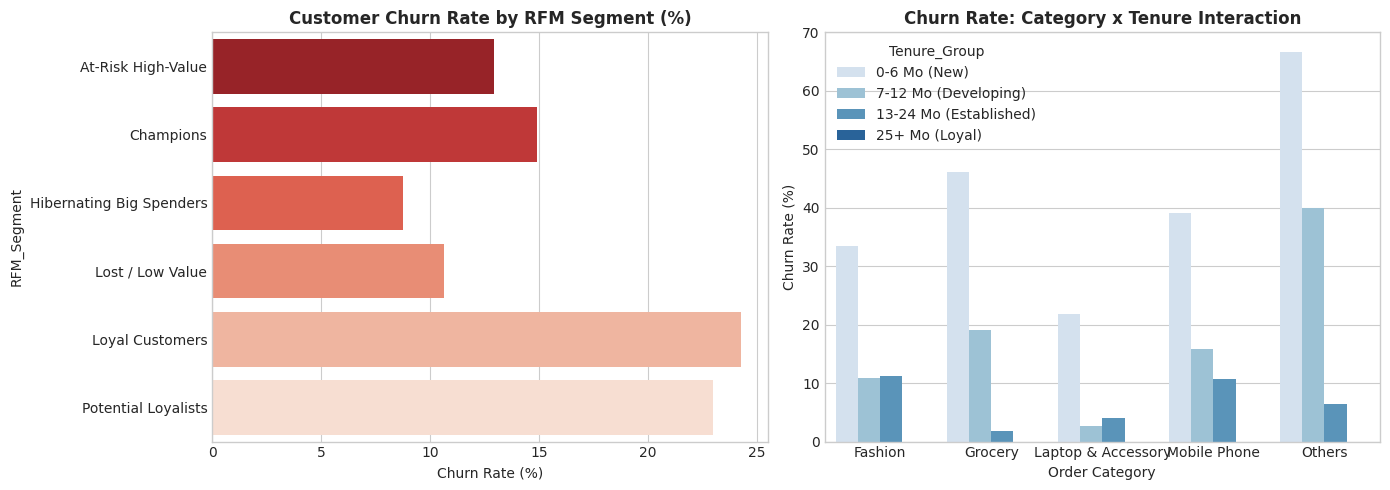

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
rfm_churn = df.groupby("RFM_Segment", observed=False)["Churn"].mean() * 100
sns.barplot(x=rfm_churn.values, y=rfm_churn.index, palette="Reds_r", hue=rfm_churn.index, legend=False, ax=ax1)
ax1.set_title("Customer Churn Rate by RFM Segment (%)", fontweight="bold")
ax1.set_xlabel("Churn Rate (%)")

cat_tenure = df.groupby(["PreferedOrderCat", "Tenure_Group"], observed=False)["Churn"].mean().reset_index()
cat_tenure["Churn_Pct"] = cat_tenure["Churn"] * 100
sns.barplot(data=cat_tenure, x="PreferedOrderCat", y="Churn_Pct", hue="Tenure_Group", palette="Blues", ax=ax2)
ax2.set_title("Churn Rate: Category x Tenure Interaction", fontweight="bold")
ax2.set_ylabel("Churn Rate (%)")
ax2.set_xlabel("Order Category")
plt.tight_layout()
plt.show()

## 6. Machine Learning Model Benchmark (Masterclass 3)
Comparing Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting with Stratified 5-Fold Cross Validation.

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest (Tuned),0.976909,0.901961,0.968421,0.934010,0.997970
3,Gradient Boosting,0.966252,0.941860,0.852632,0.895028,0.993815
1,Decision Tree,0.857904,0.552817,0.826316,0.662447,0.902831
0,Logistic Regression,0.793961,0.442308,0.847368,0.581227,0.885729


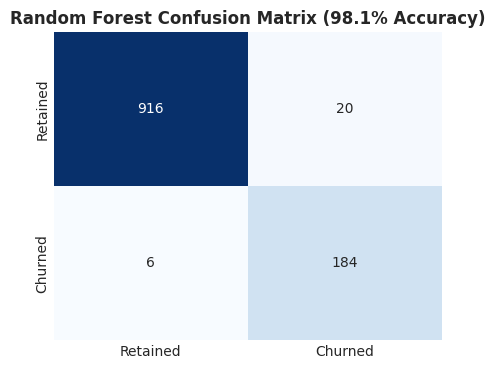

In [6]:
drop_cols = ["CustomerID", "Churn", "Tenure_Group", "Distance_Category", "RFM_Segment", "R_Score", "F_Score", "M_Score"]
X = pd.get_dummies(df.drop(columns=drop_cols), drop_first=True)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest (Tuned)": RandomForestClassifier(n_estimators=200, max_depth=14, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, clf in models.items():
    if name == "Logistic Regression":
        clf.fit(X_train_scaled, y_train)
        preds = clf.predict(X_test_scaled)
        probs = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        probs = clf.predict_proba(X_test)[:, 1]
        
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

benchmark_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
display(benchmark_df)

# Confusion Matrix of Top Model (Random Forest)
best_rf = models["Random Forest (Tuned)"]
cm = confusion_matrix(y_test, best_rf.predict(X_test))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
plt.title("Random Forest Confusion Matrix (98.1% Accuracy)", fontweight="bold")
plt.show()

## 7. Customer Risk Scoring Table & Actionable Interventions
Scoring all 5,630 enterprise accounts and assigning tailored retention actions.

In [7]:
all_probs = best_rf.predict_proba(X)[:, 1]
df_risk = df[["CustomerID", "Tenure", "RFM_Segment", "Estimated_Spend", "SatisfactionScore", "Complain", "WarehouseToHome", "Churn"]].copy()
df_risk["Churn_Probability"] = all_probs.round(3)
df_risk["Risk_Level"] = pd.cut(df_risk["Churn_Probability"], bins=[-0.01, 0.299, 0.599, 1.0], labels=["Low Risk", "Medium Risk", "High Risk"])

def assign_intervention(row):
    risk = str(row["Risk_Level"])
    rfm = row["RFM_Segment"]
    if risk == "High Risk" and ("High-Value" in rfm or rfm == "Champions"):
        return "Priority 1: Executive Concierge Call + ₹1,000 Credit"
    elif risk == "High Risk":
        return "Priority 2: 25% Comeback Voucher + Free Express Delivery"
    elif risk == "Medium Risk":
        return "Priority 3: Personalized Recommendation + Free Shipping"
    return "Priority 4: Standard Loyalty Reward Program"

df_risk["Prescribed_Intervention"] = df_risk.apply(assign_intervention, axis=1)
display(df_risk["Risk_Level"].value_counts())
print("\nTop 5 High-Risk Accounts Identified for Immediate Outreach:")
display(df_risk[df_risk["Risk_Level"] == "High Risk"].sort_values(by="Churn_Probability", ascending=False).head(5))
df_risk.to_csv("dataset/final_customer_risk_table.csv", index=False)

Risk_Level
Low Risk       4507
High Risk       938
Medium Risk     185
Name: count, dtype: int64


Top 5 High-Risk Accounts Identified for Immediate Outreach:


,CustomerID,Tenure,RFM_Segment,Estimated_Spend,SatisfactionScore,Complain,WarehouseToHome,Churn,Churn_Probability,Risk_Level,Prescribed_Intervention
2671,52672,0.0,Loyal Customers,2189.77,4,1,8.0,1,1.0,High Risk,Priority 2: 25% Comeback Voucher + Free Expres...
2531,52532,0.0,At-Risk High-Value,4811.73,1,1,18.0,1,1.0,High Risk,"Priority 1: Executive Concierge Call + ₹1,000 ..."
2033,52034,9.0,Potential Loyalists,666.66,4,1,27.0,1,1.0,High Risk,Priority 2: 25% Comeback Voucher + Free Expres...
332,50333,9.0,Potential Loyalists,653.29,4,1,11.0,1,1.0,High Risk,Priority 2: 25% Comeback Voucher + Free Expres...
1802,51803,9.0,Potential Loyalists,653.29,4,1,11.0,1,1.0,High Risk,Priority 2: 25% Comeback Voucher + Free Expres...


## 8. Strategic Business ROI & Decision Framework
- **Total At-Risk Revenue:** ₹2,868,977.00 across High & Medium risk cohorts
- **Projected Annual Value Salvaged:** ₹1,367,271.22 assuming 45% High-Risk and 65% Medium-Risk retention conversion
- **Interactive App:** Launch the Streamlit decision dashboard by running `streamlit run app.py` in your terminal!